# 04 - Train Baseline Model

This notebook trains a baseline tabular classifier before attempting sequence models such as LSTM. A strong baseline helps verify that the target, split, features, and class imbalance handling are reasonable.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# Edit this path to the location where you upload the project folder in Google Drive.
PROJECT_DIR = "/content/drive/MyDrive/fire-risk-project"
PROJECT_DIR = Path(PROJECT_DIR)

DATASET_PATH = PROJECT_DIR / "data" / "processed" / "fire_risk_dataset_2023_ndvi_firms.csv"
MODELS_DIR = PROJECT_DIR / "outputs" / "models"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"
REPORTS_DIR = PROJECT_DIR / "outputs" / "reports"

for path in [MODELS_DIR, FIGURES_DIR, REPORTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

MODEL_OUTPUT_PATH = MODELS_DIR / "random_forest_fire_risk_2023.joblib"
PREDICTIONS_OUTPUT_PATH = REPORTS_DIR / "test_predictions_2023.csv"
FEATURE_IMPORTANCE_PATH = FIGURES_DIR / "feature_importance.png"
PR_CURVE_PATH = FIGURES_DIR / "precision_recall_curve.png"


Mounted at /content/drive


In [2]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)


In [3]:
df = pd.read_csv(DATASET_PATH)
df["date"] = pd.to_datetime(df["date"])
print(df.shape)
display(df.head())
print(df["fire_risk_label"].value_counts(normalize=True, dropna=False))


(1000060, 14)


,grid_id,date,fire_count,ndvi,fire_next_7d_count,fire_count_next_7d,fire_risk_label,month,dayofyear,fire_count_lag_1d,fire_count_past_7d,fire_count_past_30d,ndvi_lag_16d,ndvi_change_16d
0,2,2023-01-01,0,0.081758,0.0,0.0,0,1,1,0.0,0.0,0.0,0.081758,0.0
1,2,2023-01-02,0,0.081758,0.0,0.0,0,1,2,0.0,0.0,0.0,0.081758,0.0
2,2,2023-01-03,0,0.081758,0.0,0.0,0,1,3,0.0,0.0,0.0,0.081758,0.0
3,2,2023-01-04,0,0.081758,0.0,0.0,0,1,4,0.0,0.0,0.0,0.081758,0.0
4,2,2023-01-05,0,0.081758,0.0,0.0,0,1,5,0.0,0.0,0.0,0.081758,0.0


fire_risk_label
0    0.989867
1    0.010133
Name: proportion, dtype: float64


In [4]:
train_df = df[df["date"] < pd.Timestamp("2023-10-01")].copy()
test_df = df[df["date"] >= pd.Timestamp("2023-10-01")].copy()

print("Train date range:", train_df["date"].min(), "to", train_df["date"].max())
print("Test date range:", test_df["date"].min(), "to", test_df["date"].max())
print("Train rows:", len(train_df))
print("Test rows:", len(test_df))


Train date range: 2023-01-01 00:00:00 to 2023-09-30 00:00:00
Test date range: 2023-10-01 00:00:00 to 2023-12-24 00:00:00
Train rows: 762570
Test rows: 237490


In [5]:
FEATURES = [
    "ndvi",
    "ndvi_change_16d",
    "month",
    "dayofyear",
    "fire_count_lag_1d",
    "fire_count_past_7d",
    "fire_count_past_30d",
]

TARGET = "fire_risk_label"

train_df = train_df.dropna(subset=FEATURES + [TARGET]).copy()
test_df = test_df.dropna(subset=FEATURES + [TARGET]).copy()

X_train = train_df[FEATURES]
y_train = train_df[TARGET].astype(int)
X_test = test_df[FEATURES]
y_test = test_df[TARGET].astype(int)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Train class counts:")
print(y_train.value_counts())
print("Test class counts:")
print(y_test.value_counts())


X_train: (762570, 7)
X_test: (237490, 7)
Train class counts:
fire_risk_label
0    754878
1      7692
Name: count, dtype: int64
Test class counts:
fire_risk_label
0    235048
1      2442
Name: count, dtype: int64


In [6]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12, n_estimators=200,
                       n_jobs=-1, random_state=42)

              precision    recall  f1-score   support

           0       1.00      0.92      0.96    235048
           1       0.08      0.69      0.15      2442

    accuracy                           0.92    237490
   macro avg       0.54      0.81      0.55    237490
weighted avg       0.99      0.92      0.95    237490

Confusion matrix [labels 0, 1]:
[[216704  18344]
 [   760   1682]]
ROC AUC: 0.9172496517762166


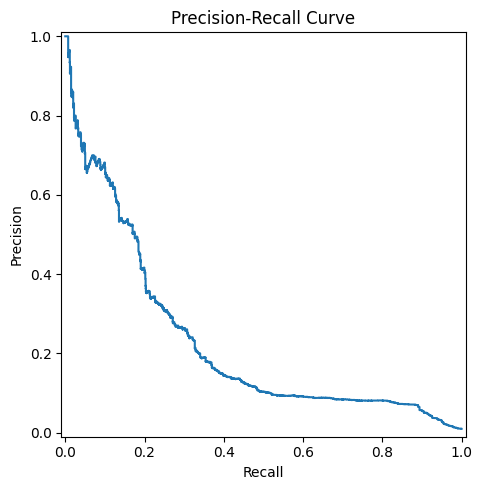

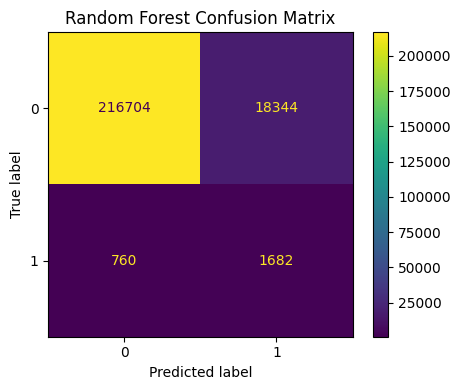

In [7]:
y_pred = rf.predict(X_test)

classes = list(rf.classes_)
if 1 in classes:
    positive_index = classes.index(1)
    y_proba = rf.predict_proba(X_test)[:, positive_index]
else:
    y_proba = np.zeros(len(X_test))

print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print("Confusion matrix [labels 0, 1]:")
print(cm)

if y_test.nunique() == 2:
    roc_auc = roc_auc_score(y_test, y_proba)
    print("ROC AUC:", roc_auc)

    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    fig, ax = plt.subplots(figsize=(6, 5))
    PrecisionRecallDisplay(precision=precision, recall=recall).plot(ax=ax)
    ax.set_title("Precision-Recall Curve")
    fig.tight_layout()
    fig.savefig(PR_CURVE_PATH, dpi=150)
    plt.show()
else:
    print("ROC AUC and precision-recall curve skipped because y_test has one class.")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=[0, 1]).plot(ax=ax, values_format="d")
ax.set_title("Random Forest Confusion Matrix")
fig.tight_layout()
plt.show()


In [8]:
joblib.dump(rf, MODEL_OUTPUT_PATH)
print(f"Saved model to {MODEL_OUTPUT_PATH}")


Saved model to /content/drive/MyDrive/fire-risk-project/outputs/models/random_forest_fire_risk_2023.joblib


In [9]:
predictions = test_df[["grid_id", "date", "fire_count", "fire_next_7d_count", "fire_risk_label"]].copy()
predictions["pred_label"] = y_pred
predictions["pred_probability"] = y_proba
predictions.to_csv(PREDICTIONS_OUTPUT_PATH, index=False)
print(f"Saved test predictions to {PREDICTIONS_OUTPUT_PATH}")
display(predictions.head())


Saved test predictions to /content/drive/MyDrive/fire-risk-project/outputs/reports/test_predictions_2023.csv


,grid_id,date,fire_count,fire_next_7d_count,fire_risk_label,pred_label,pred_probability
273,2,2023-10-01,0,0.0,0,0,0.006881
274,2,2023-10-02,0,0.0,0,0,0.006881
275,2,2023-10-03,0,0.0,0,0,0.006881
276,2,2023-10-04,0,0.0,0,0,0.006881
277,2,2023-10-05,0,0.0,0,0,0.006881


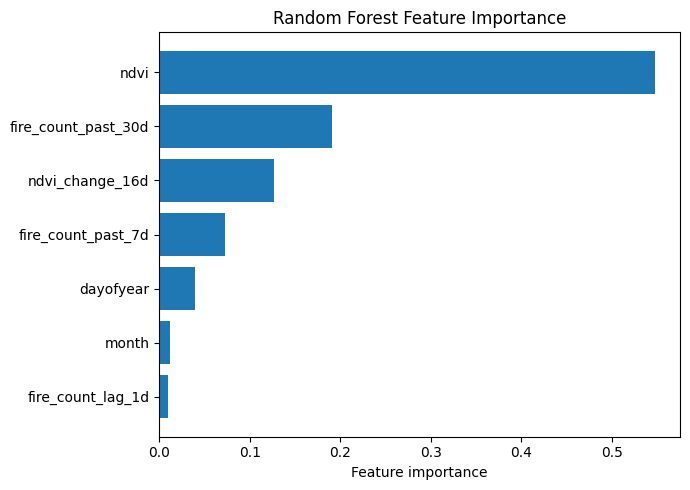

,feature,importance
0,ndvi,0.547789
6,fire_count_past_30d,0.191091
1,ndvi_change_16d,0.126771
5,fire_count_past_7d,0.072890
3,dayofyear,0.040031
2,month,0.012260
4,fire_count_lag_1d,0.009167


Saved feature importance plot to /content/drive/MyDrive/fire-risk-project/outputs/figures/feature_importance.png


In [10]:
importance = pd.DataFrame(
    {
        "feature": FEATURES,
        "importance": rf.feature_importances_,
    }
).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(importance["feature"], importance["importance"])
ax.set_xlabel("Feature importance")
ax.set_title("Random Forest Feature Importance")
fig.tight_layout()
fig.savefig(FEATURE_IMPORTANCE_PATH, dpi=150)
plt.show()

display(importance.sort_values("importance", ascending=False))
print(f"Saved feature importance plot to {FEATURE_IMPORTANCE_PATH}")


## Optional XGBoost Baseline

Set `RUN_XGBOOST = True` to train an additional gradient-boosted baseline. Keep this optional because class imbalance, runtime, and Colab hardware can vary.


In [11]:
RUN_XGBOOST = False

if RUN_XGBOOST:
    from xgboost import XGBClassifier

    xgb = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
    )
    xgb.fit(X_train, y_train)
    xgb_pred = xgb.predict(X_test)
    xgb_proba = xgb.predict_proba(X_test)[:, 1]
    print(classification_report(y_test, xgb_pred, zero_division=0))
    if y_test.nunique() == 2:
        print("XGBoost ROC AUC:", roc_auc_score(y_test, xgb_proba))


## Error Analysis

Review these slices before moving to a sequence model:

- False positives: grid-date rows predicted as fire risk when no fire appears in the next 7 days.
- False negatives: missed upcoming fire detections.
- Errors by month: seasonal bias and train/test distribution shift.
- Errors by NDVI range: vegetation-state sensitivity.
- Class imbalance problem: positive labels are expected to be rare compared with no-fire rows.


In [12]:
error_df = predictions.merge(
    test_df[["grid_id", "date", "ndvi", "month"]],
    on=["grid_id", "date"],
    how="left",
)
error_df["error_type"] = "correct"
error_df.loc[(error_df["fire_risk_label"] == 0) & (error_df["pred_label"] == 1), "error_type"] = "false_positive"
error_df.loc[(error_df["fire_risk_label"] == 1) & (error_df["pred_label"] == 0), "error_type"] = "false_negative"

print(error_df["error_type"].value_counts())
display(error_df[error_df["error_type"] == "false_positive"].head())
display(error_df[error_df["error_type"] == "false_negative"].head())

print("Errors by month:")
display(pd.crosstab(error_df["month"], error_df["error_type"]))

error_df["ndvi_bin"] = pd.cut(error_df["ndvi"], bins=[-0.2, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
print("Errors by NDVI range:")
display(pd.crosstab(error_df["ndvi_bin"], error_df["error_type"]))


error_type
correct           218386
false_positive     18344
false_negative       760
Name: count, dtype: int64


,grid_id,date,fire_count,fire_next_7d_count,fire_risk_label,pred_label,pred_probability,ndvi,month,error_type
140250,1826,2023-10-01,0,0.0,0,1,0.551074,0.20259,10,false_positive
140251,1826,2023-10-02,0,0.0,0,1,0.551074,0.20259,10,false_positive
140252,1826,2023-10-03,0,0.0,0,1,0.551074,0.20259,10,false_positive
140253,1826,2023-10-04,0,0.0,0,1,0.551074,0.20259,10,false_positive
140254,1826,2023-10-05,0,0.0,0,1,0.551074,0.20259,10,false_positive


,grid_id,date,fire_count,fire_next_7d_count,fire_risk_label,pred_label,pred_probability,ndvi,month,error_type
408,6,2023-12-08,0,1.0,1,0,0.034061,0.093338,12,false_negative
409,6,2023-12-09,0,1.0,1,0,0.034061,0.093338,12,false_negative
410,6,2023-12-10,0,1.0,1,0,0.034061,0.093338,12,false_negative
411,6,2023-12-11,0,1.0,1,0,0.034061,0.093338,12,false_negative
412,6,2023-12-12,0,1.0,1,0,0.034061,0.093338,12,false_negative


Errors by month:


error_type,correct,false_negative,false_positive
month,,,
10,79580,205,6829
11,77036,280,6504
12,61770,275,5011


Errors by NDVI range:


error_type,correct,false_negative,false_positive
ndvi_bin,,,
"(-0.2, 0.0]",165,0,0
"(0.0, 0.2]",212256,372,3118
"(0.2, 0.4]",3619,145,14062
"(0.4, 0.6]",1706,177,1146
"(0.6, 0.8]",640,66,18
